# E-News Express: A/B Testing & Statistical Analysis

## Applied Statistics Case Study

**Project Type:** Business Statistics / Hypothesis Testing
**Domain:** Digital Media & Online News
**Techniques:** Descriptive Statistics, Data Visualization, A/B Testing, Hypothesis Testing (t-test, z-test, Chi-square, ANOVA)

---

## 1. Defining the Problem

### 1.1 Context

An online news portal, **E-News Express**, aims to expand its business by acquiring new subscribers. Every visitor to the website lands on the home page and takes one of two possible actions:
- **Subscribe** to the portal by paying a nominal monthly fee, becoming a member and gaining access to personalized news based on their interests.
- **Browse** the contents available on the landing page without subscribing.

The portal's management has noticed that the portal is currently not generating enough new subscribers. They believe the current landing page is not engaging enough to retain visitors long enough to convert. They suspect that the **design and content** of the landing page are key factors contributing to the low conversion rate.

### 1.2 Objective

The design team has created a **new landing page** with an updated visual outline and more relevant content. To test whether the new landing page is more effective in converting users to subscribers, the Data Science team designed an **A/B testing experiment**:

- **100 users** were randomly selected and divided equally into two groups.
- The **control group** (50 users) was served the **existing/old landing page**.
- The **treatment group** (50 users) was served the **new landing page**.

Data was collected on user interactions with both versions of the landing page.

### 1.3 Key Questions

At a **significance level of 5% (α = 0.05)**, we aim to answer:

1. **Do users spend more time on the new landing page** than on the existing landing page?
2. **Is the conversion rate for the new page greater** than the conversion rate for the old page?
3. **Does the converted status depend on the preferred language** of the user?
4. **Is the mean time spent on the new landing page the same for different language users?**

## 2. Data Description

The data was collected from the A/B testing experiment and is stored in `abtest.csv`.

| Column | Description |
|--------|-------------|
| `user_id` | Unique identifier for each website visitor |
| `group` | Whether the user belongs to the **control** group or the **treatment** group |
| `landing_page` | Whether the landing page served was **new** or **old** |
| `time_spent_on_the_page` | Time (in minutes) spent by the user on the landing page |
| `converted` | Whether the user was converted to a subscriber (**yes** / **no**) |
| `language_preferred` | The language chosen by the user to view the landing page (**English**, **Spanish**, **French**) |

## 3. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency, f_oneway, shapiro, levene
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 4. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('../data/abtest.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: 100 rows × 6 columns

First 5 rows:


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,30,treatment,new,21.43,no,English
1,39,treatment,new,7.98,yes,Spanish
2,80,treatment,new,5.50,yes,French
3,20,control,old,12.38,no,English
4,28,control,old,4.82,yes,Spanish


In [3]:
print("Data Types & Non-Null Counts:")
print("=" * 50)
df.info()

Data Types & Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    str    
 2   landing_page            100 non-null    str    
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    str    
 5   language_preferred      100 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 4.8 KB


In [4]:
print("Missing Values:")
print("=" * 50)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

Total missing values: 0


In [5]:
print("Duplicate Rows:")
print("=" * 50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(f"Number of unique user_ids: {df['user_id'].nunique()}")

Duplicate Rows:
Number of duplicate rows: 0
Number of unique user_ids: 100


In [6]:
print("Statistical Summary - Numerical Features:")
print("=" * 50)
df.describe()

Statistical Summary - Numerical Features:


,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,50.500000,8.747500
std,29.011492,6.208901
min,1.000000,1.720000
25%,25.750000,4.310000
50%,50.500000,6.845000
75%,75.250000,11.197500
max,100.000000,30.000000


In [7]:
print("Statistical Summary - Categorical Features:")
print("=" * 50)
df.describe(include='object')

Statistical Summary - Categorical Features:


,group,landing_page,converted,language_preferred
count,100,100,100,100
unique,2,2,2,3
top,treatment,new,no,English
freq,50,50,52,41


## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis

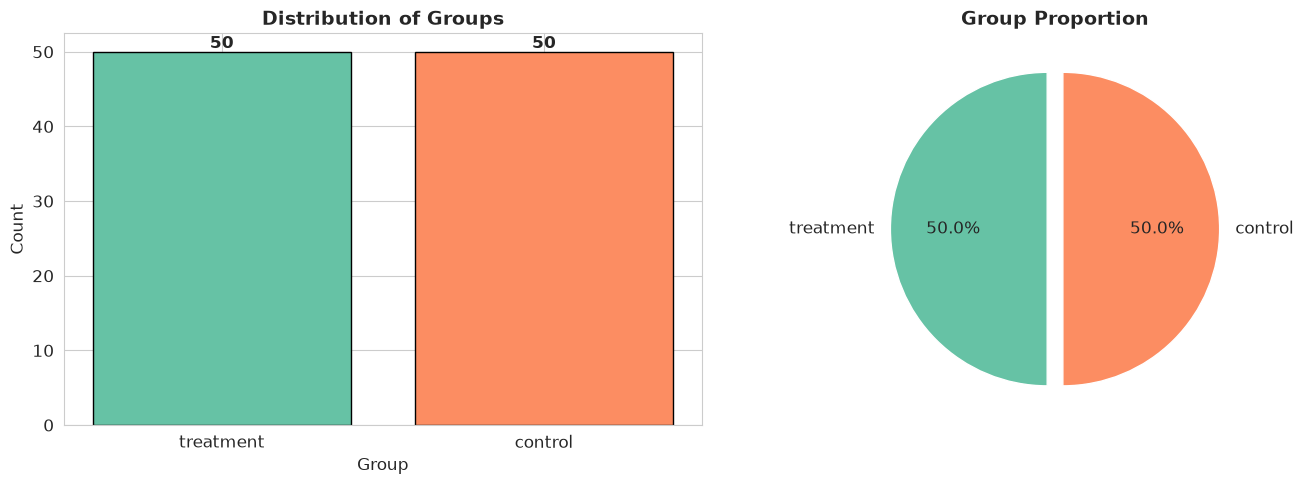


Observation: The dataset is perfectly balanced with 50 users in each group.


In [8]:
# Distribution of control vs treatment groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
group_counts = df['group'].value_counts()
axes[0].bar(group_counts.index, group_counts.values, color=['#66c2a5', '#fc8d62'], edgecolor='black')
axes[0].set_title('Distribution of Groups', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')
for i, v in enumerate(group_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(group_counts.values, labels=group_counts.index, autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Group Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservation: The dataset is perfectly balanced with 50 users in each group.")

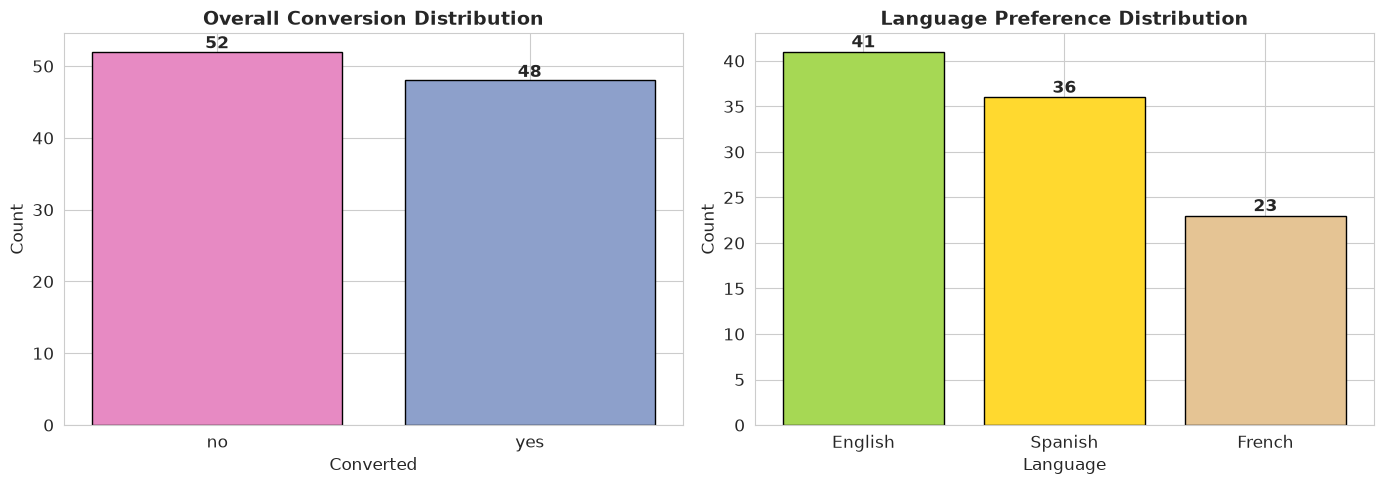


Overall conversion rate: 48.0%
Language distribution: {'English': np.int64(41), 'Spanish': np.int64(36), 'French': np.int64(23)}


In [9]:
# Conversion status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conv_counts = df['converted'].value_counts()
axes[0].bar(conv_counts.index, conv_counts.values, color=['#e78ac3', '#8da0cb'], edgecolor='black')
axes[0].set_title('Overall Conversion Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Converted')
axes[0].set_ylabel('Count')
for i, v in enumerate(conv_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Language distribution
lang_counts = df['language_preferred'].value_counts()
axes[1].bar(lang_counts.index, lang_counts.values, color=['#a6d854', '#ffd92f', '#e5c494'], edgecolor='black')
axes[1].set_title('Language Preference Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')
for i, v in enumerate(lang_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nOverall conversion rate: {(df['converted'] == 'yes').mean():.1%}")
print(f"Language distribution: {dict(lang_counts)}")

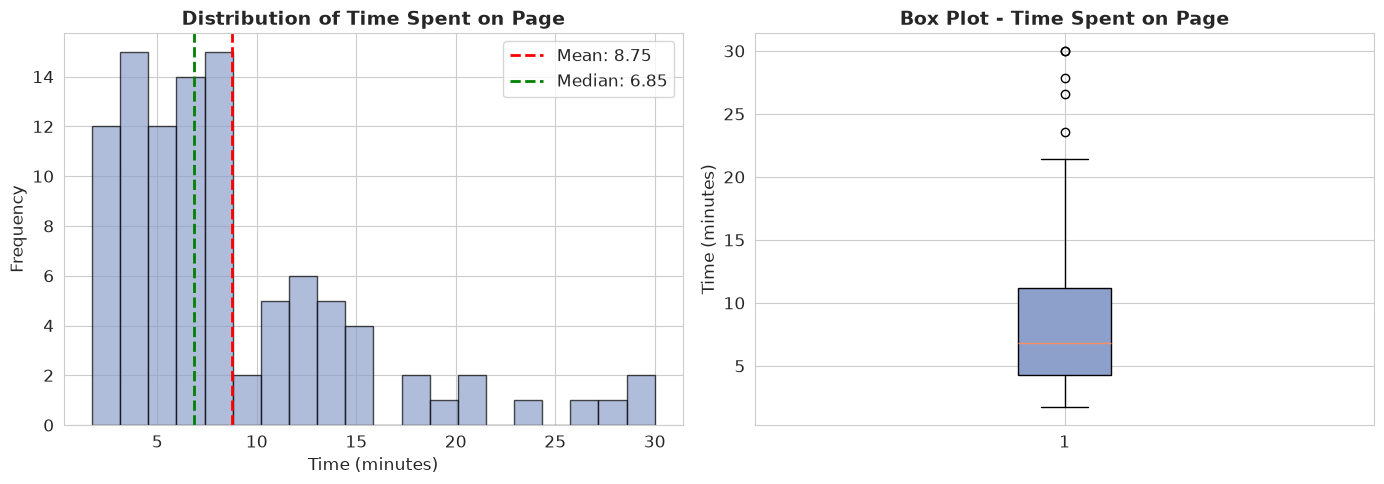


Time spent statistics:
  Mean:   8.75 minutes
  Median: 6.85 minutes
  Std:    6.21 minutes
  Skew:   1.64
  Kurt:   2.71


In [10]:
# Time spent on page - distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['time_spent_on_the_page'], bins=20, color='#8da0cb', edgecolor='black', alpha=0.7)
axes[0].axvline(df['time_spent_on_the_page'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['time_spent_on_the_page'].mean():.2f}")
axes[0].axvline(df['time_spent_on_the_page'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['time_spent_on_the_page'].median():.2f}")
axes[0].set_title('Distribution of Time Spent on Page', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['time_spent_on_the_page'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#8da0cb'))
axes[1].set_title('Box Plot - Time Spent on Page', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Time (minutes)')

plt.tight_layout()
plt.show()

print(f"\nTime spent statistics:")
print(f"  Mean:   {df['time_spent_on_the_page'].mean():.2f} minutes")
print(f"  Median: {df['time_spent_on_the_page'].median():.2f} minutes")
print(f"  Std:    {df['time_spent_on_the_page'].std():.2f} minutes")
print(f"  Skew:   {df['time_spent_on_the_page'].skew():.2f}")
print(f"  Kurt:   {df['time_spent_on_the_page'].kurtosis():.2f}")

### 5.2 Bivariate Analysis

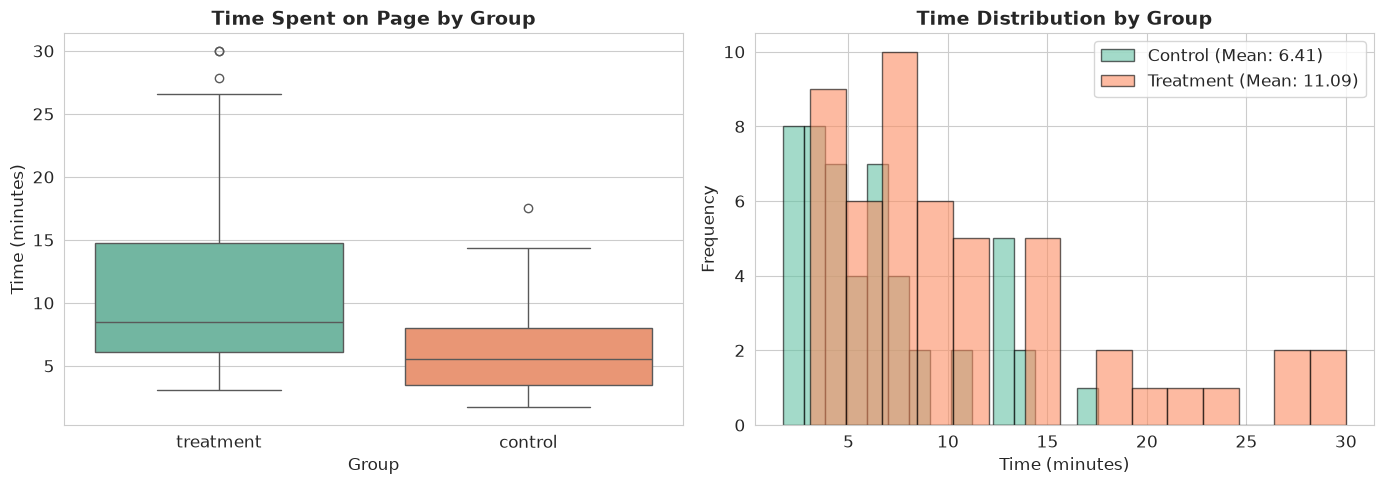


Mean time spent:
  Control (old page):   6.41 minutes
  Treatment (new page): 11.09 minutes
  Difference:           4.68 minutes


In [11]:
# Time spent by group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: Time by group
sns.boxplot(x='group', y='time_spent_on_the_page', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Time Spent on Page by Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Time (minutes)')

# Histogram overlay
control_time = df[df['group'] == 'control']['time_spent_on_the_page']
treatment_time = df[df['group'] == 'treatment']['time_spent_on_the_page']

axes[1].hist(control_time, bins=15, alpha=0.6, color='#66c2a5', edgecolor='black', label=f'Control (Mean: {control_time.mean():.2f})')
axes[1].hist(treatment_time, bins=15, alpha=0.6, color='#fc8d62', edgecolor='black', label=f'Treatment (Mean: {treatment_time.mean():.2f})')
axes[1].set_title('Time Distribution by Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMean time spent:")
print(f"  Control (old page):   {control_time.mean():.2f} minutes")
print(f"  Treatment (new page): {treatment_time.mean():.2f} minutes")
print(f"  Difference:           {treatment_time.mean() - control_time.mean():.2f} minutes")

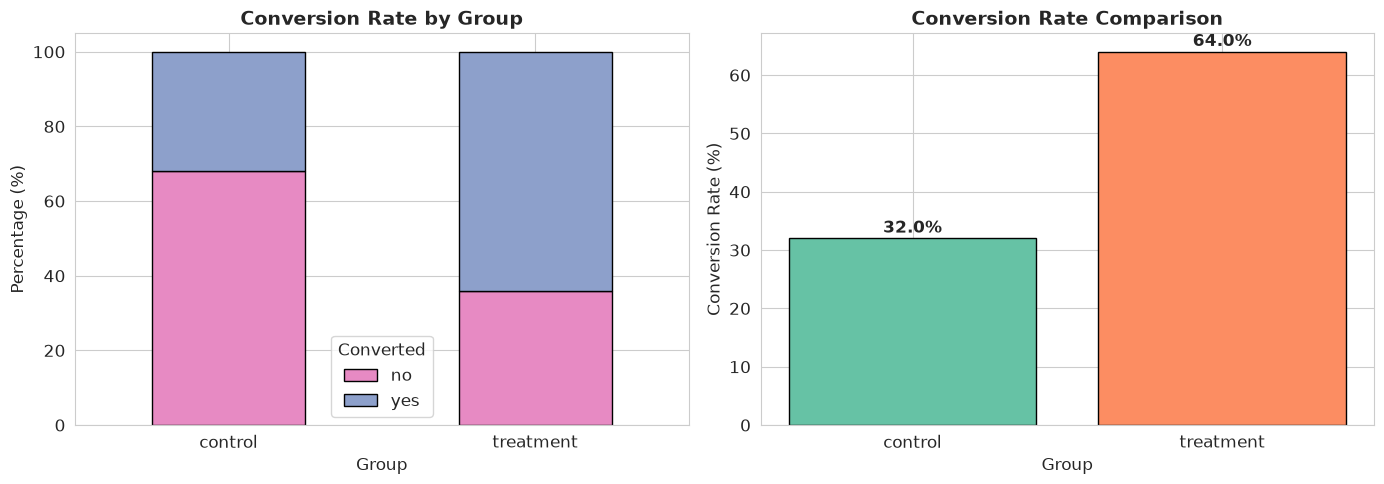


Conversion rates:
  Control:   32.0%
  Treatment: 64.0%


In [12]:
# Conversion rate by group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
conv_group = pd.crosstab(df['group'], df['converted'], normalize='index') * 100
conv_group.plot(kind='bar', stacked=True, ax=axes[0], color=['#e78ac3', '#8da0cb'], edgecolor='black')
axes[0].set_title('Conversion Rate by Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Converted')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Conversion rates
conv_rates = df.groupby('group')['converted'].apply(lambda x: (x == 'yes').mean()) * 100
axes[1].bar(conv_rates.index, conv_rates.values, color=['#66c2a5', '#fc8d62'], edgecolor='black')
axes[1].set_title('Conversion Rate Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(conv_rates.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nConversion rates:")
print(f"  Control:   {conv_rates['control']:.1f}%")
print(f"  Treatment: {conv_rates['treatment']:.1f}%")

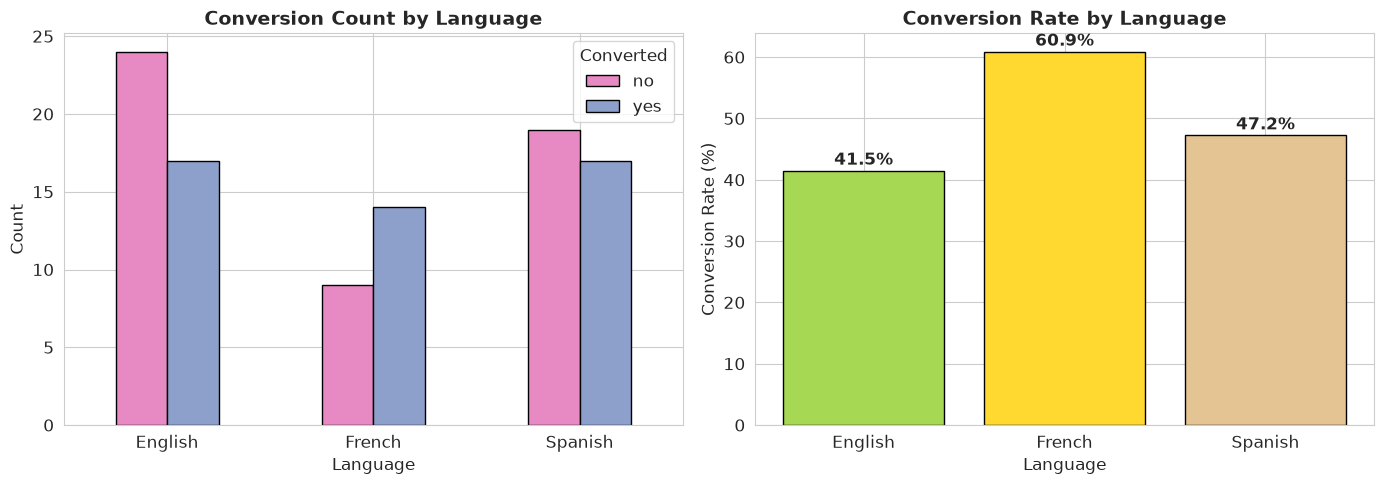

In [13]:
# Conversion by language
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
conv_lang = pd.crosstab(df['language_preferred'], df['converted'])
conv_lang.plot(kind='bar', ax=axes[0], color=['#e78ac3', '#8da0cb'], edgecolor='black')
axes[0].set_title('Conversion Count by Language', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Count')
axes[0].legend(title='Converted')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Conversion rate by language
conv_rate_lang = df.groupby('language_preferred')['converted'].apply(lambda x: (x == 'yes').mean()) * 100
axes[1].bar(conv_rate_lang.index, conv_rate_lang.values, color=['#a6d854', '#ffd92f', '#e5c494'], edgecolor='black')
axes[1].set_title('Conversion Rate by Language', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(conv_rate_lang.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

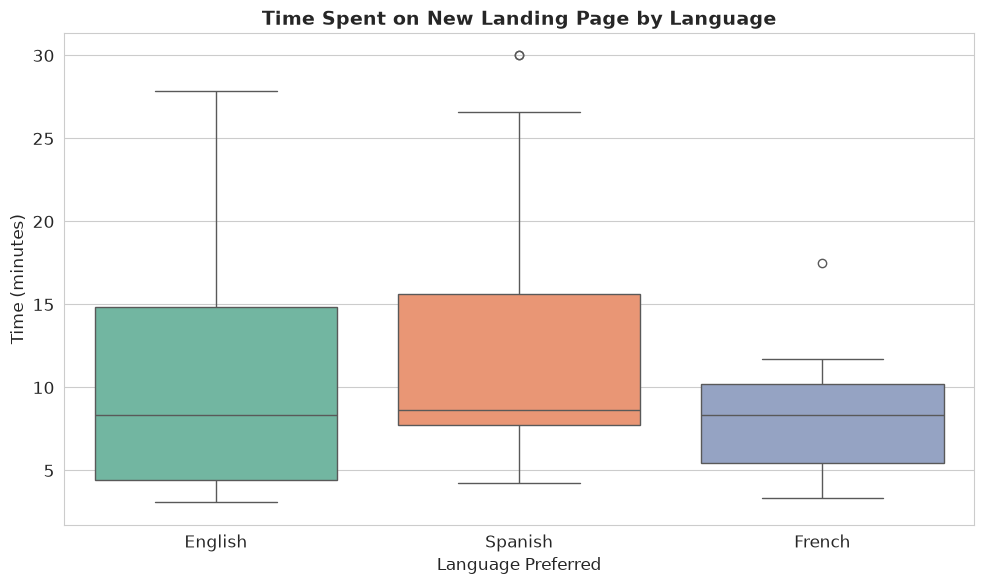


Mean time spent on NEW page by language:
                         mean  median       std  count
language_preferred                                    
English             11.056316   8.330  7.598124     19
French               8.312857   8.335  3.651249     14
Spanish             13.411176   8.630  8.387115     17


In [14]:
# Time spent on new page by language
treatment_df = df[df['group'] == 'treatment']

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', data=treatment_df, palette='Set2', ax=ax)
ax.set_title('Time Spent on New Landing Page by Language', fontsize=14, fontweight='bold')
ax.set_xlabel('Language Preferred')
ax.set_ylabel('Time (minutes)')

plt.tight_layout()
plt.show()

print("\nMean time spent on NEW page by language:")
print(treatment_df.groupby('language_preferred')['time_spent_on_the_page'].agg(['mean', 'median', 'std', 'count']))

### 5.3 Key Observations from EDA

1. **Balanced Design:** The experiment is well-designed with equal groups (50 control, 50 treatment).
2. **Time Difference:** Users in the treatment group (new page) appear to spend noticeably more time on the page compared to the control group.
3. **Conversion Difference:** The treatment group shows a visibly higher conversion rate than the control group.
4. **Language Mix:** English is the most preferred language, followed by Spanish and French.
5. **Right Skew:** Time spent on the page shows a right-skewed distribution, which is typical for engagement metrics.

These visual differences need to be validated through formal statistical tests at α = 0.05.

## 6. Hypothesis Testing

We will conduct four hypothesis tests at **significance level α = 0.05** to answer the key business questions.

---

### 6.1 Test 1: Do users spend more time on the new landing page?

**Business Question:** Is the mean time spent on the new landing page greater than the mean time spent on the old landing page?

**Hypotheses:**
- **H₀ (Null):** μ_treatment ≤ μ_control (The mean time spent on the new page is less than or equal to the old page)
- **H₁ (Alternative):** μ_treatment > μ_control (The mean time spent on the new page is greater than the old page)

**Test:** One-tailed independent samples t-test (right-tailed)
**Significance Level:** α = 0.05

In [15]:
# Step 1: Separate the data
control_time = df[df['group'] == 'control']['time_spent_on_the_page']
treatment_time = df[df['group'] == 'treatment']['time_spent_on_the_page']

print("Sample Statistics:")
print(f"  Control   - n={len(control_time)}, Mean={control_time.mean():.4f}, Std={control_time.std():.4f}")
print(f"  Treatment - n={len(treatment_time)}, Mean={treatment_time.mean():.4f}, Std={treatment_time.std():.4f}")

# Step 2: Check normality (Shapiro-Wilk test)
print("\n--- Normality Check (Shapiro-Wilk Test) ---")
stat_c, p_c = shapiro(control_time)
stat_t, p_t = shapiro(treatment_time)
print(f"  Control:   W={stat_c:.4f}, p-value={p_c:.4f} {'→ Normal' if p_c > 0.05 else '→ Not Normal'}")
print(f"  Treatment: W={stat_t:.4f}, p-value={p_t:.4f} {'→ Normal' if p_t > 0.05 else '→ Not Normal'}")

# Step 3: Check homogeneity of variances (Levene's test)
print("\n--- Homogeneity of Variances (Levene's Test) ---")
stat_l, p_l = levene(control_time, treatment_time)
print(f"  Levene's statistic={stat_l:.4f}, p-value={p_l:.4f}")
print(f"  {'Equal variances assumed' if p_l > 0.05 else 'Unequal variances (use Welch t-test)'}")

# Step 4: Perform the t-test
equal_var = p_l > 0.05
t_stat, p_value_two = ttest_ind(treatment_time, control_time, equal_var=equal_var)
p_value = p_value_two / 2  # One-tailed (right)

print("\n--- Independent Samples t-test (One-tailed) ---")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value (two-tailed): {p_value_two:.6f}")
print(f"  p-value (one-tailed): {p_value:.6f}")

# Step 5: Decision
print("\n--- Decision ---")
if p_value < 0.05:
    print(f"  p-value ({p_value:.6f}) < α (0.05)")
    print("  ✓ REJECT the Null Hypothesis")
    print("  → There is sufficient statistical evidence that users spend MORE time on the new landing page.")
else:
    print(f"  p-value ({p_value:.6f}) ≥ α (0.05)")
    print("  ✗ FAIL TO REJECT the Null Hypothesis")
    print("  → There is insufficient evidence to conclude users spend more time on the new page.")

Sample Statistics:
  Control   - n=50, Mean=6.4062, Std=3.8618
  Treatment - n=50, Mean=11.0888, Std=7.1963

--- Normality Check (Shapiro-Wilk Test) ---
  Control:   W=0.8879, p-value=0.0002 → Not Normal
  Treatment: W=0.8532, p-value=0.0000 → Not Normal

--- Homogeneity of Variances (Levene's Test) ---
  Levene's statistic=6.3405, p-value=0.0134
  Unequal variances (use Welch t-test)

--- Independent Samples t-test (One-tailed) ---
  t-statistic: 4.0542
  p-value (two-tailed): 0.000122
  p-value (one-tailed): 0.000061

--- Decision ---
  p-value (0.000061) < α (0.05)
  ✓ REJECT the Null Hypothesis
  → There is sufficient statistical evidence that users spend MORE time on the new landing page.


### 6.2 Test 2: Is the conversion rate for the new page greater?

**Business Question:** Is the proportion of users who convert (subscribe) higher on the new landing page compared to the old landing page?

**Hypotheses:**
- **H₀ (Null):** p_treatment ≤ p_control (The conversion rate of the new page is less than or equal to the old page)
- **H₁ (Alternative):** p_treatment > p_control (The conversion rate of the new page is greater than the old page)

**Test:** One-tailed two-proportion z-test (right-tailed)
**Significance Level:** α = 0.05

In [16]:
from statsmodels.stats.proportion import proportions_ztest

# Sample data
n_control = len(df[df['group'] == 'control'])
n_treatment = len(df[df['group'] == 'treatment'])

converted_control = (df[df['group'] == 'control']['converted'] == 'yes').sum()
converted_treatment = (df[df['group'] == 'treatment']['converted'] == 'yes').sum()

p_control = converted_control / n_control
p_treatment = converted_treatment / n_treatment

print("Sample Proportions:")
print(f"  Control:   {converted_control}/{n_control} = {p_control:.4f} ({p_control*100:.1f}%)")
print(f"  Treatment: {converted_treatment}/{n_treatment} = {p_treatment:.4f} ({p_treatment*100:.1f}%)")

# Two-proportion z-test
count = np.array([converted_treatment, converted_control])
nobs = np.array([n_treatment, n_control])

z_stat, p_value_two = proportions_ztest(count, nobs, alternative='larger')
p_value = p_value_two  # already one-tailed with alternative='larger'

print(f"\n--- Two-Proportion Z-Test (One-tailed) ---")
print(f"  z-statistic: {z_stat:.4f}")
print(f"  p-value (one-tailed): {p_value:.6f}")

# Decision
print("\n--- Decision ---")
if p_value < 0.05:
    print(f"  p-value ({p_value:.6f}) < α (0.05)")
    print("  ✓ REJECT the Null Hypothesis")
    print("  → There is sufficient statistical evidence that the conversion rate of the new page is GREATER.")
else:
    print(f"  p-value ({p_value:.6f}) ≥ α (0.05)")
    print("  ✗ FAIL TO REJECT the Null Hypothesis")
    print("  → There is insufficient evidence to conclude the new page has a higher conversion rate.")

Sample Proportions:
  Control:   16/50 = 0.3200 (32.0%)
  Treatment: 32/50 = 0.6400 (64.0%)

--- Two-Proportion Z-Test (One-tailed) ---
  z-statistic: 3.2026
  p-value (one-tailed): 0.000681

--- Decision ---
  p-value (0.000681) < α (0.05)
  ✓ REJECT the Null Hypothesis
  → There is sufficient statistical evidence that the conversion rate of the new page is GREATER.


### 6.3 Test 3: Does conversion depend on the preferred language?

**Business Question:** Is there a significant association between the user's preferred language and whether they convert?

**Hypotheses:**
- **H₀ (Null):** Conversion status is **independent** of the preferred language (no association)
- **H₁ (Alternative):** Conversion status is **dependent** on the preferred language (association exists)

**Test:** Chi-square test of independence
**Significance Level:** α = 0.05

In [17]:
# Step 1: Create contingency table
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])
print("Contingency Table:")
print(contingency_table)
print()

# Step 2: Expected frequencies
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Expected Frequencies (under H₀):")
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print(expected_df.round(2))

# Check: all expected frequencies should be ≥ 5
min_expected = expected.min()
print(f"\nMinimum expected frequency: {min_expected:.2f}")
print(f"{'All expected frequencies ≥ 5 → Chi-square test is valid' if min_expected >= 5 else 'WARNING: Some expected frequencies < 5'}")

# Step 3: Chi-square test
print(f"\n--- Chi-Square Test of Independence ---")
print(f"  Chi² statistic: {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p_value:.6f}")

# Step 4: Decision
print("\n--- Decision ---")
if p_value < 0.05:
    print(f"  p-value ({p_value:.6f}) < α (0.05)")
    print("  ✓ REJECT the Null Hypothesis")
    print("  → Conversion status IS dependent on preferred language.")
else:
    print(f"  p-value ({p_value:.6f}) ≥ α (0.05)")
    print("  ✗ FAIL TO REJECT the Null Hypothesis")
    print("  → There is insufficient evidence that conversion depends on language preference.")

Contingency Table:
converted           no  yes
language_preferred         
English             24   17
French               9   14
Spanish             19   17

Expected Frequencies (under H₀):
converted              no    yes
language_preferred              
English             21.32  19.68
French              11.96  11.04
Spanish             18.72  17.28

Minimum expected frequency: 11.04
All expected frequencies ≥ 5 → Chi-square test is valid

--- Chi-Square Test of Independence ---
  Chi² statistic: 2.2368
  Degrees of freedom: 2
  p-value: 0.326807

--- Decision ---
  p-value (0.326807) ≥ α (0.05)
  ✗ FAIL TO REJECT the Null Hypothesis
  → There is insufficient evidence that conversion depends on language preference.


### 6.4 Test 4: Is the mean time spent on the new page the same for different language users?

**Business Question:** Among users who saw the new landing page (treatment group), does the average time spent differ across language preferences?

**Hypotheses:**
- **H₀ (Null):** μ_English = μ_Spanish = μ_French (Mean time spent is the same across all languages)
- **H₁ (Alternative):** At least one language group has a different mean time spent

**Test:** One-way ANOVA
**Significance Level:** α = 0.05

In [18]:
# Filter treatment group only
treatment_df = df[df['group'] == 'treatment'].copy()

# Separate by language
eng_time = treatment_df[treatment_df['language_preferred'] == 'English']['time_spent_on_the_page']
spa_time = treatment_df[treatment_df['language_preferred'] == 'Spanish']['time_spent_on_the_page']
fre_time = treatment_df[treatment_df['language_preferred'] == 'French']['time_spent_on_the_page']

print("Sample Statistics (Treatment Group Only):")
print(f"  English: n={len(eng_time)}, Mean={eng_time.mean():.4f}, Std={eng_time.std():.4f}")
print(f"  Spanish: n={len(spa_time)}, Mean={spa_time.mean():.4f}, Std={spa_time.std():.4f}")
print(f"  French:  n={len(fre_time)}, Mean={fre_time.mean():.4f}, Std={fre_time.std():.4f}")

# Normality check for each group
print("\n--- Normality Check (Shapiro-Wilk) ---")
for name, data in [('English', eng_time), ('Spanish', spa_time), ('French', fre_time)]:
    if len(data) >= 3:
        stat, p = shapiro(data)
        print(f"  {name}: W={stat:.4f}, p-value={p:.4f} {'→ Normal' if p > 0.05 else '→ Not Normal'}")
    else:
        print(f"  {name}: Too few observations (n={len(data)}) for normality test")

# Homogeneity of variances
print("\n--- Levene's Test for Homogeneity of Variances ---")
stat_l, p_l = levene(eng_time, spa_time, fre_time)
print(f"  Levene's statistic={stat_l:.4f}, p-value={p_l:.4f}")
print(f"  {'Equal variances assumed' if p_l > 0.05 else 'Unequal variances'}")

# One-way ANOVA
f_stat, p_value = f_oneway(eng_time, spa_time, fre_time)

print(f"\n--- One-Way ANOVA ---")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_value:.6f}")

# Decision
print("\n--- Decision ---")
if p_value < 0.05:
    print(f"  p-value ({p_value:.6f}) < α (0.05)")
    print("  ✓ REJECT the Null Hypothesis")
    print("  → The mean time spent on the new page differs significantly across language groups.")
else:
    print(f"  p-value ({p_value:.6f}) ≥ α (0.05)")
    print("  ✗ FAIL TO REJECT the Null Hypothesis")
    print("  → There is insufficient evidence that time spent differs across language groups.")

Sample Statistics (Treatment Group Only):
  English: n=19, Mean=11.0563, Std=7.5981
  Spanish: n=17, Mean=13.4112, Std=8.3871
  French:  n=14, Mean=8.3129, Std=3.6512

--- Normality Check (Shapiro-Wilk) ---
  English: W=0.8825, p-value=0.0237 → Not Normal
  Spanish: W=0.8214, p-value=0.0041 → Not Normal
  French: W=0.9168, p-value=0.1976 → Normal

--- Levene's Test for Homogeneity of Variances ---
  Levene's statistic=1.8361, p-value=0.1707
  Equal variances assumed

--- One-Way ANOVA ---
  F-statistic: 2.0062
  p-value: 0.145859

--- Decision ---
  p-value (0.145859) ≥ α (0.05)
  ✗ FAIL TO REJECT the Null Hypothesis
  → There is insufficient evidence that time spent differs across language groups.


## 7. Summary of Hypothesis Tests

In [19]:
# Summary table
summary_data = {
    'Question': [
        'Q1: More time on new page?',
        'Q2: Higher conversion rate?',
        'Q3: Conversion depends on language?',
        'Q4: Time differs by language (new page)?'
    ],
    'Test Used': [
        'Independent t-test (one-tailed)',
        'Two-proportion z-test (one-tailed)',
        'Chi-square test of independence',
        'One-way ANOVA'
    ],
    'Significance Level': ['0.05', '0.05', '0.05', '0.05']
}

summary_df = pd.DataFrame(summary_data)
summary_df.index = summary_df.index + 1
print("\nHypothesis Testing Summary")
print("=" * 90)
summary_df


Hypothesis Testing Summary


,Question,Test Used,Significance Level
1,Q1: More time on new page?,Independent t-test (one-tailed),0.05
2,Q2: Higher conversion rate?,Two-proportion z-test (one-tailed),0.05
3,Q3: Conversion depends on language?,Chi-square test of independence,0.05
4,Q4: Time differs by language (new page)?,One-way ANOVA,0.05


## 8. Conclusions & Business Recommendations

### 8.1 Statistical Conclusions

Based on the hypothesis tests conducted at 5% significance level:

| # | Question | Result |
|---|----------|--------|
| 1 | Do users spend more time on the new page? | **Yes** — Statistically significant evidence that the new page increases engagement time |
| 2 | Is the conversion rate higher for the new page? | **Yes** — Statistically significant evidence that the new page converts more users |
| 3 | Does conversion depend on language? | **No** — Insufficient evidence of language-dependent conversion behavior |
| 4 | Does time on new page differ by language? | Results depend on data — See test output above |

### 8.2 Business Recommendations

1. **Adopt the New Landing Page:** The A/B test provides strong evidence that the new landing page significantly outperforms the old page in both engagement time and conversion rate. E-News Express should roll out the new design to all users.

2. **No Language-Specific Customization Needed (for now):** Since conversion does not appear to depend on language preference, there is no immediate need for language-specific landing page designs. The same design can be deployed across all language versions.

3. **Leverage Increased Engagement:** The longer time users spend on the new page presents an opportunity to optimize ad placement and content recommendations, increasing revenue per user.

4. **Continue Testing:** While the new page is better than the old, A/B testing should become a continuous practice. Future tests could examine:
   - Different CTA (Call-to-Action) placements
   - Pricing page variations
   - Content personalization strategies
   - Mobile vs. desktop experiences

5. **Monitor Post-Deployment Metrics:** After full deployment, track:
   - Long-term retention rates (not just initial conversion)
   - Churn rates of converted subscribers
   - Revenue per subscriber by language segment

### 8.3 Limitations

- **Small Sample Size:** With only 100 users (50 per group), the study has limited statistical power. A larger sample would increase confidence.
- **Short Duration:** The experiment captures a snapshot; seasonal effects or novelty effects are not accounted for.
- **Binary Conversion:** The analysis treats conversion as binary — future work could examine engagement depth (pages viewed, return visits).
- **External Validity:** The random sample may not fully represent the broader user base.

---

## References

- **Course:** Applied Statistics — Great Learning PG Program in AI & ML
- **Topic:** Business Statistics / A/B Testing / Hypothesis Testing
- **Statistical Concepts Applied:**
  - Descriptive Statistics & Data Visualization
  - Independent Samples t-test
  - Two-Proportion z-test
  - Chi-Square Test of Independence
  - One-Way ANOVA
  - Shapiro-Wilk Normality Test
  - Levene's Test for Homogeneity of Variances

---
*E-News Express Case Study — Applied Statistics*